In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
FEATURE_COLS = [
    'total_orders',
    'total_spend',
    'avg_order_value',
    'max_order_value',
    'min_order_value',
    'customer_age_days',
    'avg_review_score',
    'avg_delivery_days',
    'pct_on_time',
    'num_categories',
    'has_repeat_orders',
    'avg_days_between_orders',
    'avg_freight_ratio',
    'avg_delivery_delta',
    'gave_low_review',
    'gave_high_review',
    'has_review',
    'review_missing',
    'is_consumable_category',
    'spend_tier'
]

In [3]:
import pickle

In [4]:

# Load calibrated model
with open(
    r"C:\Users\Pavitra\Downloads\olist-Project\notebooks\xgb_churn_model_calibrated.pkl",
    "rb"
) as f:
    calibrated_model = pickle.load(f)

In [5]:
customer_features = pd.read_csv(r"C:\Users\Pavitra\Downloads\Olist_E-Commerce_Analysis\notebooks\customer_features_final.csv")

In [6]:
# Predict sigmoid calibrated churn probabilities for all customers

X_all = customer_features[FEATURE_COLS].fillna(0)

churn_probability = calibrated_model.predict_proba(X_all)[:, 1]

customer_features['churn_probability'] = churn_probability

customer_features['risk_tier'] = pd.cut(
    churn_probability,
    bins=[0, 0.3, 0.6, 0.8, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk', 'Critical Risk'],
    include_lowest=True
)

print("Churn probability distribution:")
print(customer_features['risk_tier'].value_counts().sort_index())

Churn probability distribution:
risk_tier
Low Risk         19311
Medium Risk      20263
High Risk        25391
Critical Risk    28385
Name: count, dtype: int64


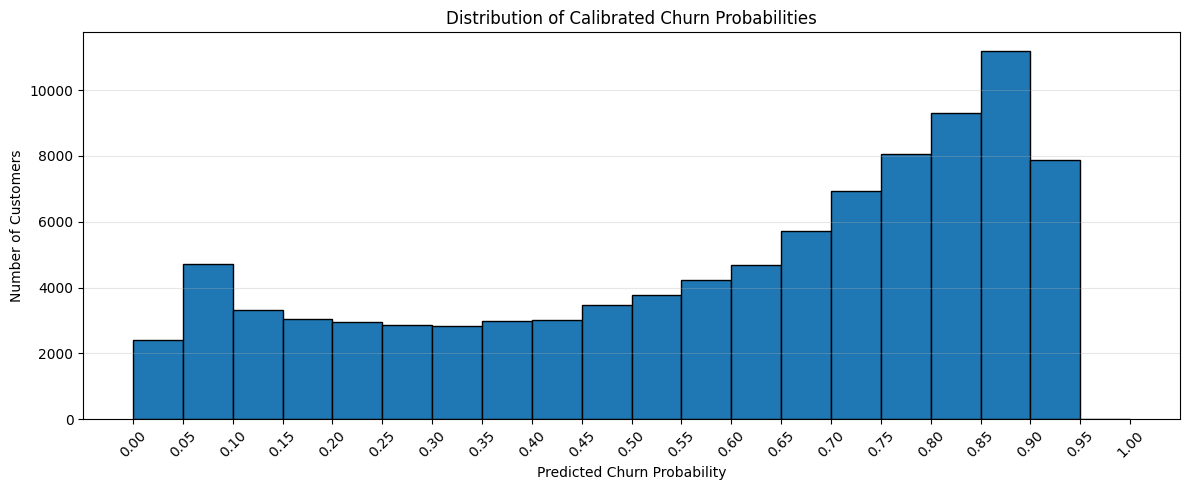

In [7]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

bins = np.arange(0, 1.05, 0.05)   # 0.00, 0.05, ..., 1.00

plt.hist(
    customer_features['churn_probability'],
    bins=bins,
    edgecolor='black'
)

plt.xlabel("Predicted Churn Probability")
plt.ylabel("Number of Customers")
plt.title("Distribution of Calibrated Churn Probabilities")
plt.xticks(bins, rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:

high_risk = customer_features[(customer_features['churn_probability'] >= 0.6) & (customer_features['churn_probability'] < 0.8)]
critical_risk = customer_features[customer_features['churn_probability'] >= 0.8]


In [9]:
avg_order_value = customer_features['avg_order_value'].mean()
avg_order_value

np.float64(160.31543448142764)

In [10]:
#  REVENUE AT RISK CALCULATION



print("=" * 60)
print("BUSINESS IMPACT ANALYSIS")
print("=" * 60)

print(f"\nHigh-risk customers (P(churn) >= 0.60 and < 0.80):")
print(f"  Count: {len(high_risk):,}")
print(f"  Total historical spend: R${high_risk['total_spend'].sum():,.0f}")
print(f"  Average spend per customer: R${high_risk['total_spend'].mean():,.0f}")

print(f"\nCritical-risk customers (P(churn) >= 0.80):")
print(f"  Count: {len(critical_risk):,}")
print(f"  Total historical spend: R${critical_risk['total_spend'].sum():,.0f}")
print(f"  Total historical average spend: R${critical_risk['total_spend'].mean():,.0f}")



BUSINESS IMPACT ANALYSIS

High-risk customers (P(churn) >= 0.60 and < 0.80):
  Count: 25,391
  Total historical spend: R$4,915,189
  Average spend per customer: R$194

Critical-risk customers (P(churn) >= 0.80):
  Count: 28,385
  Total historical spend: R$3,660,871
  Total historical average spend: R$129


In [11]:
high_risk["total_orders"].sum()/len(high_risk)

np.float64(1.0236698042613523)

In [12]:
## A potential retention campaign according to the Calibrated model

# Assumption: If a high-value customer churns, we lose their expected future order

avg_order_value = high_risk['avg_order_value'].mean()
expected_annual_orders = 1.024  # conservative assumption:going by numbers
retention_rate=0.10

revenue_at_risk = len(high_risk) * avg_order_value * expected_annual_orders

print(f"\n{'='*60}")
print(f"ESTIMATED ANNUAL REVENUE AT RISK: R${revenue_at_risk:,.0f}")
print(f"{'='*60}")
print(f"\nAssumptions:")
print(f"  - Avg order value: R${avg_order_value:.0f}")
print(f"  - Expected orders/year: {expected_annual_orders}")
print(f"  - At-risk customers: {len(high_risk):,}")

# Retention campaign ROI

campaign_cost_per_customer = 10  # R$5 in discount/email cost

revenue_saved = len(high_risk) * retention_rate * avg_order_value * expected_annual_orders
campaign_cost = len(high_risk) * campaign_cost_per_customer
campaign_roi = (revenue_saved - campaign_cost) / campaign_cost * 100

print(f"\nRETENTION CAMPAIGN SCENARIO (15% retention rate):")
print(f"  Customers retained: {int(len(high_risk) * retention_rate):,}")
print(f"  Revenue saved: R${revenue_saved:,.0f}")
print(f"  Campaign cost: R${campaign_cost:,.0f}")
print(f"  Campaign ROI: {campaign_roi:.0f}%")


ESTIMATED ANNUAL REVENUE AT RISK: R$4,939,722

Assumptions:
  - Avg order value: R$190
  - Expected orders/year: 1.024
  - At-risk customers: 25,391

RETENTION CAMPAIGN SCENARIO (15% retention rate):
  Customers retained: 2,539
  Revenue saved: R$493,972
  Campaign cost: R$253,910
  Campaign ROI: 95%


In [13]:
customer_features.to_csv(
    r"C:\Users\Pavitra\Downloads\olist-Project\notebooks\customer_features_final_calibrated.csv",
    index=False
)

print("customer_features_final_calibrated.csv updated.")

customer_features_final_calibrated.csv updated.


In [14]:
churn_risk_summary = (
    customer_features
    .groupby("risk_tier")
    .agg(
        customer_count=("customer_unique_id", "count"),
        total_spend=("total_spend", "sum"),
        avg_order_value=("avg_order_value", "mean"),
        avg_churn_probability=("churn_probability", "mean")
    )
    .reset_index()
)

risk_order = [
    "Low Risk",
    "Medium Risk",
    "High Risk",
    "Critical Risk"
]

churn_risk_summary["risk_tier"] = pd.Categorical(
    churn_risk_summary["risk_tier"],
    categories=risk_order,
    ordered=True
)

churn_risk_summary = (
    churn_risk_summary
    .sort_values("risk_tier")
    .reset_index(drop=True)
)

churn_risk_summary.to_csv(
    r"C:\Users\Pavitra\Downloads\olist-Project\notebooks\churn_risk_summary.csv",
    index=False
)

print("churn_risk_summary.csv updated.")

churn_risk_summary.csv updated.


In [15]:
print(customer_features["risk_tier"].value_counts())

print()

print(churn_risk_summary)

risk_tier
Critical Risk    28385
High Risk        25391
Medium Risk      20263
Low Risk         19311
Name: count, dtype: int64

       risk_tier  customer_count  total_spend  avg_order_value  \
0       Low Risk           19311   2877869.63       141.458508   
1    Medium Risk           20263   3967296.35       191.266904   
2      High Risk           25391   4915189.45       189.986513   
3  Critical Risk           28385   3660870.88       124.507723   

   avg_churn_probability  
0               0.147206  
1               0.462566  
2               0.711860  
3               0.870862  
